# F2.1 — Obtención y exploración inicial del conjunto de datos

**Proyecto Transversal MCDI500 — Grupo 8 — Universidad Andrés Bello**
Módulo: Programación para la Ciencia de Datos · Fase 2

---

## Propósito de este notebook

Este notebook cubre las dos primeras etapas de la Fase 2: **obtener** el conjunto de
datos de forma trazable y **explorarlo** para diagnosticar su estado real.

No se modifica ni un solo valor aquí. La exploración tiene una función precisa dentro
del proyecto: **producir la evidencia que justifica cada decisión** del pipeline de
limpieza que se implementa en `F2_02`. Sin este diagnóstico, las transformaciones
posteriores serían arbitrarias.

## Conjunto de datos

| Campo | Valor |
|---|---|
| Nombre | Pondsdata |
| Autor | Arepalli Peda Gopi |
| Fuente | https://www.kaggle.com/datasets/apgopi/pondsdata |
| Contexto | Tres estanques de acuicultura monitoreados por sensores IoT |
| Ubicación | Guntur, Andhra Pradesh, India |
| Cobertura | Febrero 2022 – Enero 2023 |
| Cadencia nominal | Una lectura cada 20 minutos (72 diarias) |

## Preguntas que guían la exploración

1. ¿Qué estructura tiene el archivo y qué representa cada columna?
2. ¿Qué proporción de valores está ausente y dónde se concentra?
3. ¿Hay valores que impiden tratar las columnas numéricas como números?
4. ¿Existen registros duplicados y bajo qué criterio?
5. ¿La cadencia de 20 minutos se cumple realmente o el registro tiene interrupciones?
6. ¿Hay valores fuera del rango que un instrumento puede medir?

Cada respuesta se traduce en una etapa concreta del pipeline de `F2_02`.

---
## 1. Configuración del entorno reproducible

La primera celda resuelve la raíz del proyecto buscando hacia arriba la carpeta
`src/ponds`. Así el notebook funciona igual si se ejecuta desde `F2/` en JupyterLab
o desde la raíz del repositorio con `nbconvert`, sin rutas absolutas escritas a mano.

In [1]:
import sys
from pathlib import Path


def raiz_proyecto() -> Path:
    """Localiza la raiz del repositorio a partir del directorio de trabajo."""
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "src" / "ponds").is_dir():
            return base
    raise RuntimeError(
        "No se encontro 'src/ponds'. Ejecute el notebook dentro del repositorio."
    )


RAIZ = raiz_proyecto()
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

print("Raiz del proyecto:", RAIZ)

Raiz del proyecto: C:\Users\mcidf\Documents\proyecto-ponds


### 1.1 Registro del entorno

Se deja constancia de las versiones utilizadas. Este bloque es la evidencia de
reproducibilidad: cualquier integrante puede comparar su salida con la del informe y
detectar de inmediato una discrepancia de versiones.

In [2]:
import platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns

entorno = pd.DataFrame(
    [
        ("Fecha de ejecucion", datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("Sistema operativo", f"{platform.system()} {platform.release()}"),
        ("Python", platform.python_version()),
        ("Interprete", sys.executable),
        ("numpy", np.__version__),
        ("pandas", pd.__version__),
        ("matplotlib", matplotlib.__version__),
        ("seaborn", sns.__version__),
    ],
    columns=["Componente", "Version"],
)
entorno

,Componente,Version
0,Fecha de ejecucion,2026-09-13 23:51:16
1,Sistema operativo,Windows 10
2,Python,3.10.11
3,Interprete,C:\Users\mcidf\Documents\proyecto-ponds\.venv\...
4,numpy,2.1.0
5,pandas,2.2.2
6,matplotlib,3.9.2
7,seaborn,0.13.2


In [3]:
# Modulos propios del proyecto. Toda la logica de procesamiento vive en src/ponds:
# este notebook solo orquesta llamadas, nunca reimplementa una transformacion.
from ponds import rutas, io_datos, perfilado, temporal, graficos

rutas.asegurar_directorios()
graficos.aplicar_estilo()

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print("Paquete 'ponds' importado correctamente")
print("Archivo fuente configurado:", rutas.ARCHIVO_CRUDO)

Paquete 'ponds' importado correctamente
Archivo fuente configurado: Ponds data.csv


---
## 2. Obtención del conjunto de datos

Kaggle exige autenticación y responde con un desafío *reCAPTCHA* ante cualquier
descarga automatizada, por lo que **la descarga se realiza manualmente** y el código
parte del archivo ya presente en `data/raw/`. Esta limitación está documentada en
`docs/decisiones.md` (D-01).

Para que la descarga manual no rompa la trazabilidad, `io_datos` calcula el
**SHA-256** de cada archivo. Ese hash es la prueba de que el análisis se ejecutó
sobre exactamente el mismo contenido: si alguien sustituye el CSV, el hash cambia y
la diferencia queda a la vista en lugar de pasar inadvertida.

In [4]:
# Descomprime el ZIP de Kaggle si sigue presente; es idempotente.
csvs = io_datos.descomprimir_si_existe(rutas.DIR_CRUDO / "pondsdata.zip")

print(f"Archivos CSV disponibles en data/raw/ ({len(csvs)}):")
for c in csvs:
    print(f"  - {c.name:<24} {c.stat().st_size / 1e6:>7.2f} MB")

Archivos CSV disponibles en data/raw/ (5):
  - Aquaponds Dataset.csv       4.35 MB
  - Fish Ponds.csv              4.34 MB
  - Ponds data.csv              6.51 MB
  - Ponds.csv                   1.07 MB
  - Ponds1.csv                  6.36 MB


### 2.1 Elección del archivo fuente

El ZIP contiene cinco CSV que son versiones sucesivas del mismo registro. Se compara
su estructura para elegir con criterio, no por el nombre del archivo.

In [5]:
comparativa = []
for c in csvs:
    muestra = pd.read_csv(c, nrows=5, dtype=str)
    completo = pd.read_csv(c, usecols=[0], dtype=str)
    comparativa.append(
        {
            "archivo": c.name,
            "filas": len(completo),
            "columnas": muestra.shape[1],
            "tiene_estacion": any("station" in x.lower() for x in muestra.columns),
            "tiene_fecha": any("date" in x.lower() for x in muestra.columns),
            "tiene_hora": any("time" in x.lower() for x in muestra.columns),
            "nombres": ", ".join(muestra.columns[:4]) + " ...",
        }
    )

pd.DataFrame(comparativa).sort_values("filas", ascending=False)

,archivo,filas,columnas,tiene_estacion,tiene_fecha,tiene_hora,nombres
2,Ponds data.csv,74796,11,True,True,True,"station, Date, Time, NITRATE(PPM) ..."
4,Ponds1.csv,74796,10,True,True,True,"station, Date, Time, NITRATE(PPM) ..."
1,Fish Ponds.csv,74758,8,False,False,False,"NITRATE(PPM), PH, AMMONIA(mg/l), TEMP ..."
0,Aquaponds Dataset.csv,50000,11,True,True,True,"station, Date, Time, NITRATE(PPM) ..."
3,Ponds.csv,18102,9,True,True,False,"Station, Date, NITRATE(PPM), PH ..."


**Decisión (D-02).** Se selecciona **`Ponds data.csv`** como fuente primaria porque es
el único archivo que reúne las tres condiciones necesarias para un análisis temporal:

- conserva el **identificador de estanque** (`station`), sin el cual no se pueden
  separar las tres series;
- conserva **fecha y hora** por separado, lo que permite reconstruir la marca temporal;
- contiene el registro completo (~74.800 filas), frente a `Ponds.csv`, que está
  agregado a 18.102 filas y ya perdió la cadencia original.

`Fish Ponds.csv` se descarta pese a estar más limpio: **carece de columnas temporales
y de estanque**, de modo que sus filas no son ubicables en el tiempo. Preferir un
archivo pre-limpiado habría eliminado el objeto mismo de la Fase 2.

In [6]:
df_crudo = io_datos.cargar_crudo()

print(f"Dimensiones: {df_crudo.shape[0]:,} filas x {df_crudo.shape[1]} columnas")
print(f"Memoria:     {df_crudo.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_crudo.head()

Dimensiones: 74,796 filas x 11 columnas
Memoria:     52.5 MB


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label
0,station1,01-02-2022,08:00:00,18.3,5.7,0.01,23.2,11.6,31.7,0.71,0
1,station1,01-02-2022,08:20:00,3.6,5.1,0.094,23.41,10.5,18.8,0.62,0
2,station1,01-02-2022,08:40:00,13.1,5.5,0.06,23.63,10.3,23.2,0.73,0
3,station1,01-02-2022,09:00:00,18.1,5.2,0.018,23.64,9.4,26.7,0.64,0
4,station1,01-02-2022,09:20:00,10.8,5.2,0.038,23.81,8.8,19.5,0.68,0


> **Nota técnica sobre la carga.** `cargar_crudo()` lee **todas** las columnas como
> texto (`dtype=str`) y sólo considera ausente la celda literalmente vacía. Es
> deliberado: si se dejara que pandas infiriera los tipos, las columnas contaminadas
> quedarían como `object` de forma silenciosa y el problema aparecería más tarde, en
> medio de un cálculo. Leer en crudo permite **contar** los defectos antes de
> corregirlos, que es justamente el propósito de este notebook.

In [7]:
# Registro de procedencia: origen, licencia, fecha de descarga y hash de cada archivo.
destino = io_datos.registrar_procedencia()
print("Registro de procedencia escrito en:", destino.relative_to(RAIZ))

pd.DataFrame([io_datos.describir_fuente(rutas.DIR_CRUDO / rutas.ARCHIVO_CRUDO)]).T.rename(
    columns={0: "valor"}
)

Registro de procedencia escrito en: data\raw\README_DATOS.md


,valor
archivo,Ponds data.csv
ruta_relativa,data\raw\Ponds data.csv
tamano_mb,6.508
sha256,101523d7f3e99749afcaa1a37c5ce0d0d4d3f109c86a1b...
leido_el,2026-09-13 23:51:17


---
## 3. Exploración inicial

### 3.1 Estructura y diccionario de variables

In [8]:
diccionario = pd.DataFrame(
    [
        {
            "columna_original": orig,
            "columna_normalizada": nuevo,
            "unidad": rutas.UNIDADES.get(nuevo, "-"),
            "descripcion": rutas.DESCRIPCION_VARIABLES.get(nuevo, "-"),
        }
        for orig, nuevo in rutas.RENOMBRE_COLUMNAS.items()
    ]
)
diccionario

,columna_original,columna_normalizada,unidad,descripcion
0,station,estanque,-,Identificador del estanque monitoreado (statio...
1,NITRATE(PPM),nitrato,ppm,Concentracion de nitrato; producto final de la...
2,PH,ph,adimensional,Acidez o alcalinidad del agua.
3,AMMONIA(mg/l),amonio,mg/L,Amonio total; toxico para los peces en concent...
4,TEMP,temperatura,grados Celsius,Temperatura del agua; gobierna el metabolismo ...
5,DO,oxigeno_disuelto,mg/L,Oxigeno disuelto; variable critica para la sup...
6,TURBIDITY,turbidez,NTU,Turbidez; mide solidos en suspension y penetra...
7,MANGANESE(mg/l),manganeso,mg/L,Concentracion de manganeso disuelto.
8,label,etiqueta_calidad,-,"Etiqueta binaria de la fuente: 0 = agua apta, ..."


In [9]:
resumen = perfilado.resumen_columnas(df_crudo)
resumen

,columna,dtype,n_nulos,pct_nulos,n_unicos,ejemplos
0,station,object,38,0.051,3,"station1, station1"
1,Date,object,38,0.051,355,"01-02-2022, 01-02-2022"
2,Time,object,89,0.119,72,"08:00:00, 08:20:00"
3,NITRATE(PPM),object,38,0.051,53319,"18.3, 3.6"
4,PH,object,38,0.051,46257,"5.7, 5.1"
5,AMMONIA(mg/l),object,38,0.051,22186,"0.01, 0.094"
6,TEMP,object,44,0.059,51767,"23.2, 23.41"
7,DO,object,42,0.056,53675,"11.6, 10.5"
8,TURBIDITY,object,38,0.051,49773,"31.7, 18.8"
9,MANGANESE(mg/l),object,57,0.076,44454,"0.71, 0.62"


**Hallazgo H-01 — Ninguna columna llegó con el tipo correcto.**
Las once columnas aparecen como `object`. En un archivo de mediciones de sensores se
esperaría que las siete variables físicas fueran numéricas: que no lo sean indica que
cada una contiene al menos un valor no convertible a número. Se cuantifica en §3.3.

### 3.2 Valores ausentes

In [10]:
nulos = perfilado.reporte_nulos(df_crudo)
nulos

,columna,n_nulos,pct_nulos
0,Time,89,0.119
1,MANGANESE(mg/l),57,0.076
2,TEMP,44,0.059
3,DO,42,0.056
4,station,38,0.051
5,Date,38,0.051
6,NITRATE(PPM),38,0.051
7,AMMONIA(mg/l),38,0.051
8,PH,38,0.051
9,TURBIDITY,38,0.051


Figura guardada en: docs\figuras\f01_mapa_nulos.png


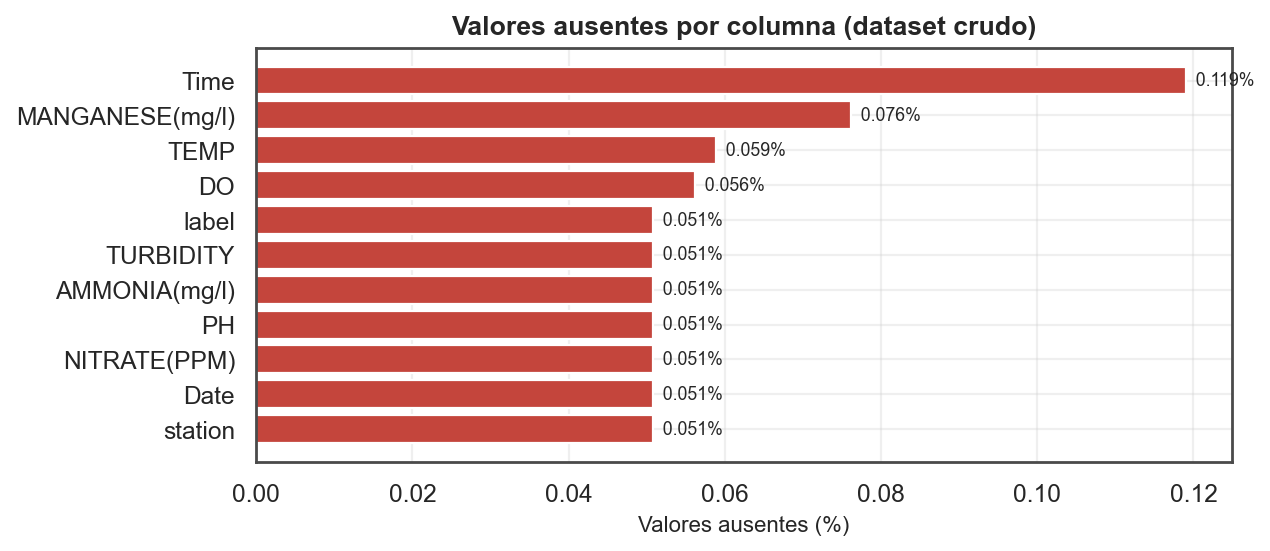

In [11]:
ruta_fig = graficos.mapa_nulos(df_crudo)
print("Figura guardada en:", ruta_fig.relative_to(RAIZ))

from IPython.display import Image, display
display(Image(filename=str(ruta_fig)))

**Hallazgo H-02 — Los ausentes se concentran en 38 filas completamente vacías.**
Todas las columnas presentan exactamente 38 nulos, salvo `Time` (89), `MANGANESE`
(57), `TEMP` (44) y `DO` (42). Ese suelo común de 38 no es casual: corresponde a filas
en las que **todos** los campos están vacíos, artefacto típico de una exportación
desde hoja de cálculo. Se verifica a continuación.

In [12]:
filas_vacias = df_crudo.isna().all(axis=1)

print(f"Filas completamente vacias: {filas_vacias.sum()}")
print(f"Total de celdas nulas:      {df_crudo.isna().sum().sum()}")
print(f"  - aportadas por filas vacias: {filas_vacias.sum() * df_crudo.shape[1]}")
print(f"  - ausentes reales (resto):    "
      f"{df_crudo.isna().sum().sum() - filas_vacias.sum() * df_crudo.shape[1]}")

df_crudo[filas_vacias].head(3)

Filas completamente vacias: 38
Total de celdas nulas:      498
  - aportadas por filas vacias: 418
  - ausentes reales (resto):    80


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label
74758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Confirmado: de las 498 celdas nulas, 418 provienen de esas 38 filas fantasma. Los
**ausentes reales son sólo 80**, repartidos en cuatro columnas. La distinción importa:
eliminar las filas vacías es una operación sin pérdida de información, mientras que
tratar los 80 ausentes reales sí requiere una decisión justificada.

→ *Se traduce en la etapa 3 del pipeline (`eliminar_filas_vacias`).*

### 3.3 Valores que impiden la conversión numérica

Se comprueba la sospecha de H-01: qué contienen exactamente las columnas que deberían
ser numéricas y no lo son.

In [13]:
columnas_numericas = [c for c in rutas.RENOMBRE_COLUMNAS if c != "station"]
no_convertibles = perfilado.valores_no_convertibles(df_crudo, columnas_numericas)
no_convertibles[no_convertibles["n_no_convertibles"] > 0]

,columna,n_no_convertibles,valores_encontrados
0,NITRATE(PPM),6,"'#VALUE!' x4, 'NaN' x2"
1,PH,2,"'NaN' x1, '#VALUE!' x1"
4,DO,6,"'#VALUE!' x4, 'NaN' x2"
6,MANGANESE(mg/l),6,"'#VALUE!' x4, 'NaN' x2"


**Hallazgo H-03 — El archivo arrastra dos codificaciones distintas de "sin dato".**

- **`#VALUE!`** (13 celdas): error de fórmula de Microsoft Excel. Confirma que el CSV
  se exportó desde una hoja de cálculo y que ese paso introdujo errores.
- **`'NaN'` como texto** (7 celdas): la cadena literal, no el valor nulo. pandas **no**
  la reconoce como ausente, así que se propaga silenciosamente y basta para forzar
  toda la columna a `object`.

Veinte celdas sobre 74.796 filas bastan para inutilizar cuatro variables. Es el
ejemplo más claro de por qué el casting no puede darse por supuesto.

→ *Se traduce en las etapas 2 (`normalizar_centinelas`) y 5 (`convertir_tipos`).*

In [14]:
# Localizacion de los registros afectados, para dejar constancia de casos concretos.
mask = df_crudo.isin(["#VALUE!", "NaN"]).any(axis=1)
print(f"Filas afectadas por centinelas de texto: {mask.sum()}")
df_crudo[mask].head(6)

Filas afectadas por centinelas de texto: 9


,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),label
3190,station1,17-03-2022,15:20:00,NaN,5,0.014,29.33,7.8,22.2,0.74,0
6182,station1,27-04-2022,04:40:00,11,6.1,0.106,28.15,NaN,35.8,NaN,0
6201,station1,28-04-2022,11:00:00,NaN,NaN,0.118,30.44,NaN,20.1,NaN,0
26988,Station2,17-03-2022,15:00:00,#VALUE!,4.99,0.0140336,29.68196,7.7064,22.644,0.73556,0
29980,Station2,27-04-2022,04:20:00,11.396,6.0878,0.107908,28.4878,#VALUE!,36.1222,#VALUE!,0
29999,Station2,28-04-2022,10:40:00,#VALUE!,#VALUE!,0.120124,30.80528,#VALUE!,20.2809,#VALUE!,0


### 3.4 Consistencia del identificador de estanque

In [15]:
df_crudo["station"].value_counts(dropna=False).rename("n_registros").to_frame()

,n_registros
station,
Station2,25498
Station3,25461
station1,23799
NaN,38


**Hallazgo H-04 — Capitalización inconsistente.** Conviven `station1` en minúscula con
`Station2` y `Station3` con inicial mayúscula. Un `groupby` agruparía los tres
correctamente, pero cualquier filtro escrito a mano (`df[df.station == "station2"]`)
devolvería un conjunto vacío **sin error**, que es la peor clase de fallo.

→ *Se traduce en la etapa 4 (`normalizar_estanque`).*

### 3.5 Registros duplicados

In [16]:
perfilado.reporte_duplicados(df_crudo, claves=["station", "Date", "Time"])

,criterio,n_filas,pct
0,duplicados exactos (todas las columnas),37,0.0495
1,"duplicados por clave ('station', 'Date', 'Time')",83,0.1110


**Hallazgo H-05 — Los duplicados son un efecto secundario de los registros incompletos.**
Los 37 duplicados exactos son las propias filas fantasma (38 filas idénticas producen
37 repeticiones). Los 83 duplicados por clave se explican porque la clave contiene
componentes nulos: las filas vacías y las que no tienen hora colisionan entre sí al
compartir esos nulos. Una vez descartados esos registros **no queda ningún duplicado
real**, lo que se verifica en la bitácora de `F2_02`.

→ *Se traduce en la etapa 7 (`eliminar_duplicados`), que se ejecuta después de
eliminar las filas vacías precisamente por este motivo.*

### 3.6 Estadísticos descriptivos y rangos físicos

Para poder calcular estadísticos se convierte a numérico **sólo en una copia de
trabajo**; el dataset original permanece intacto.

In [17]:
df_num = df_crudo.rename(columns=rutas.RENOMBRE_COLUMNAS).copy()
for col in rutas.VARIABLES:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

perfilado.estadisticos(df_num)

,variable,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis,n_nulos,unidad
0,nitrato,74752.0,38.6758,35.7546,0.0000,16.0000,27.5450,39.4919,153.3952,1.5564,1.4925,44,ppm
1,ph,74756.0,6.5434,1.1096,4.5001,5.7000,6.4000,7.3027,9.0068,0.3787,-0.6932,40,adimensional
2,amonio,74758.0,0.0962,0.1599,0.0010,0.0296,0.0448,0.1031,1.8720,5.2149,32.7008,38,mg/L
3,temperatura,74752.0,27.2258,5.9717,0.0000,22.9216,26.8192,30.4300,45.4995,0.5917,0.3876,44,grados Celsius
4,oxigeno_disuelto,74748.0,10.7602,5.5095,0.0000,6.5673,9.1000,14.9907,25.4976,0.6028,-0.5038,48,mg/L
5,turbidez,74758.0,31.5889,11.6298,10.2000,22.8617,30.0872,37.2708,82.0922,1.0148,1.1436,38,NTU
6,manganeso,74733.0,0.9808,0.7712,0.2000,0.5541,0.7057,0.9557,3.5762,1.7785,2.1693,63,mg/L


In [18]:
perfilado.fuera_de_rango(df_num, rutas.RANGOS_FISICOS, etiqueta="fisico")

,variable,fisico_min,fisico_max,n_bajo_minimo,n_sobre_maximo,n_total_fuera,pct_fuera
0,nitrato,0.0,500.0,0,0,0,0.000
1,ph,0.0,14.0,0,0,0,0.000
2,amonio,0.0,10.0,0,0,0,0.000
3,temperatura,5.0,50.0,12,0,12,0.016
4,oxigeno_disuelto,0.0,30.0,0,0,0,0.000
5,turbidez,0.0,1000.0,0,0,0,0.000
6,manganeso,0.0,10.0,0,0,0,0.000


**Hallazgo H-06 — Doce lecturas de temperatura igual a 0.0 °C.** Cero grados en un
estanque tropical de Andhra Pradesh no es un valor extremo: es **imposible**. Se
inspecciona el contexto de esas doce filas.

In [19]:
sospechosas = df_num[df_num["temperatura"] == 0]
print(f"Registros con temperatura = 0.0: {len(sospechosas)}")
print("Estanques afectados:", sospechosas["estanque"].unique().tolist())
print("Fechas afectadas:   ", sospechosas["Date"].unique().tolist())
print("Rango horario:      ", sospechosas["Time"].min(), "-", sospechosas["Time"].max())

sospechosas[["estanque", "Date", "Time", "temperatura", "oxigeno_disuelto", "ph"]]

Registros con temperatura = 0.0: 12
Estanques afectados: ['Station2', 'Station3']
Fechas afectadas:    ['27-02-2022']
Rango horario:       05:00:00 - 07:00:00


,estanque,Date,Time,temperatura,oxigeno_disuelto,ph
25734,Station2,27-02-2022,05:00:00,0.0,2.120580,7.38760
25735,Station2,27-02-2022,05:20:00,0.0,0.201960,8.09600
25736,Station2,27-02-2022,05:40:00,0.0,1.514700,8.70320
25737,Station2,27-02-2022,06:00:00,0.0,1.009800,8.90560
25738,Station2,27-02-2022,06:20:00,0.0,1.110780,7.59000
25739,Station2,27-02-2022,06:40:00,0.0,2.221560,7.99480
51233,Station3,27-02-2022,05:20:00,0.0,2.082410,6.07282
51234,Station3,27-02-2022,05:40:00,0.0,0.198325,5.93462
51235,Station3,27-02-2022,06:00:00,0.0,1.487435,5.78584
51236,Station3,27-02-2022,06:20:00,0.0,0.991624,5.42853


In [20]:
# Las mismas fecha y franja horaria en el otro estanque, para contrastar.
contexto = df_num[
    (df_num["Date"] == "27-02-2022")
    & (df_num["Time"].between("05:00:00", "07:00:00"))
][["estanque", "Date", "Time", "temperatura"]].sort_values(["estanque", "Time"])

contexto

,estanque,Date,Time,temperatura
25734,Station2,27-02-2022,05:00:00,0.000000
25735,Station2,27-02-2022,05:20:00,0.000000
25736,Station2,27-02-2022,05:40:00,0.000000
25737,Station2,27-02-2022,06:00:00,0.000000
25738,Station2,27-02-2022,06:20:00,0.000000
25739,Station2,27-02-2022,06:40:00,0.000000
25740,Station2,27-02-2022,07:00:00,24.237400
51232,Station3,27-02-2022,05:00:00,23.411861
51233,Station3,27-02-2022,05:20:00,0.000000
51234,Station3,27-02-2022,05:40:00,0.000000


Los doce ceros se concentran en **un único evento**: la madrugada del 27-02-2022,
entre las 05:00 y las 07:00. `Station2` y `Station3` registran seis lecturas de `0.0`
cada uno, y en esa misma ventana `station1` registra `NaN` (tabla anterior). Se trata
de **un mismo fallo de instrumento que afectó a los tres estanques y quedó codificado
de dos formas distintas**: como nulo en uno y como cero en los otros dos.

La consecuencia práctica es directa: si esos ceros se tratasen como mediciones
válidas, hundirían cualquier media de temperatura y sugerirían un evento de frío
extremo que nunca ocurrió.

→ *Se traduce en la etapa 8 (`anular_fallos_de_sensor`), que convierte el valor en
nulo **sin eliminar la fila**: el resto de variables de esa observación sigue siendo
válido.*

### 3.7 Distribución de las variables

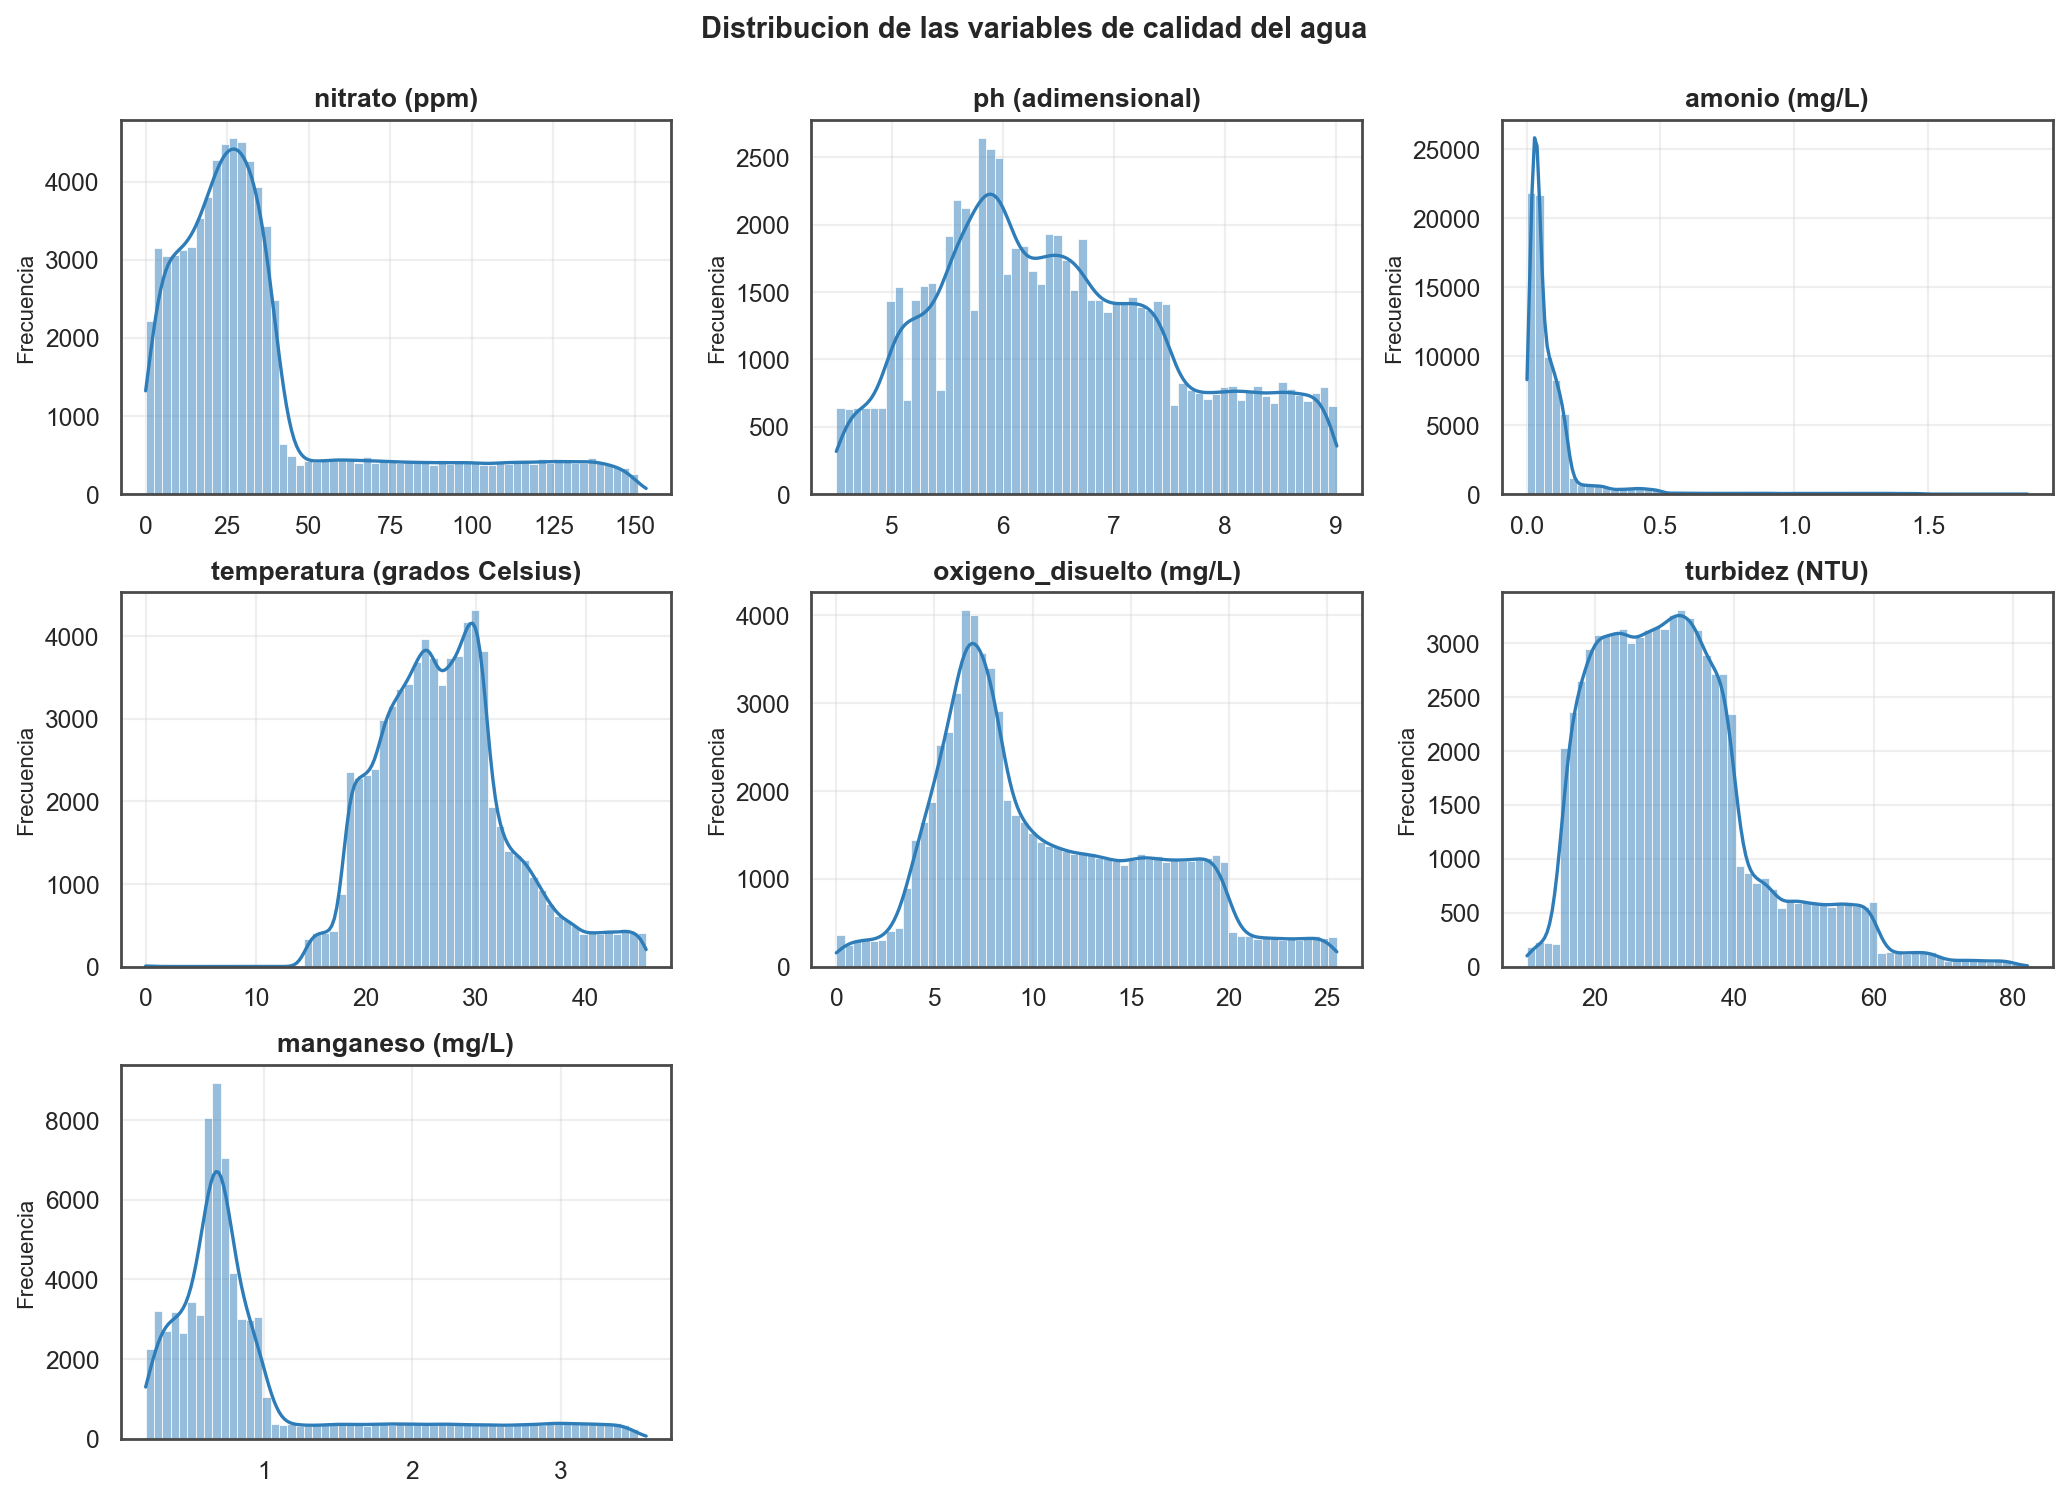

In [21]:
fig_dist = graficos.distribuciones(df_num)
display(Image(filename=str(fig_dist)))

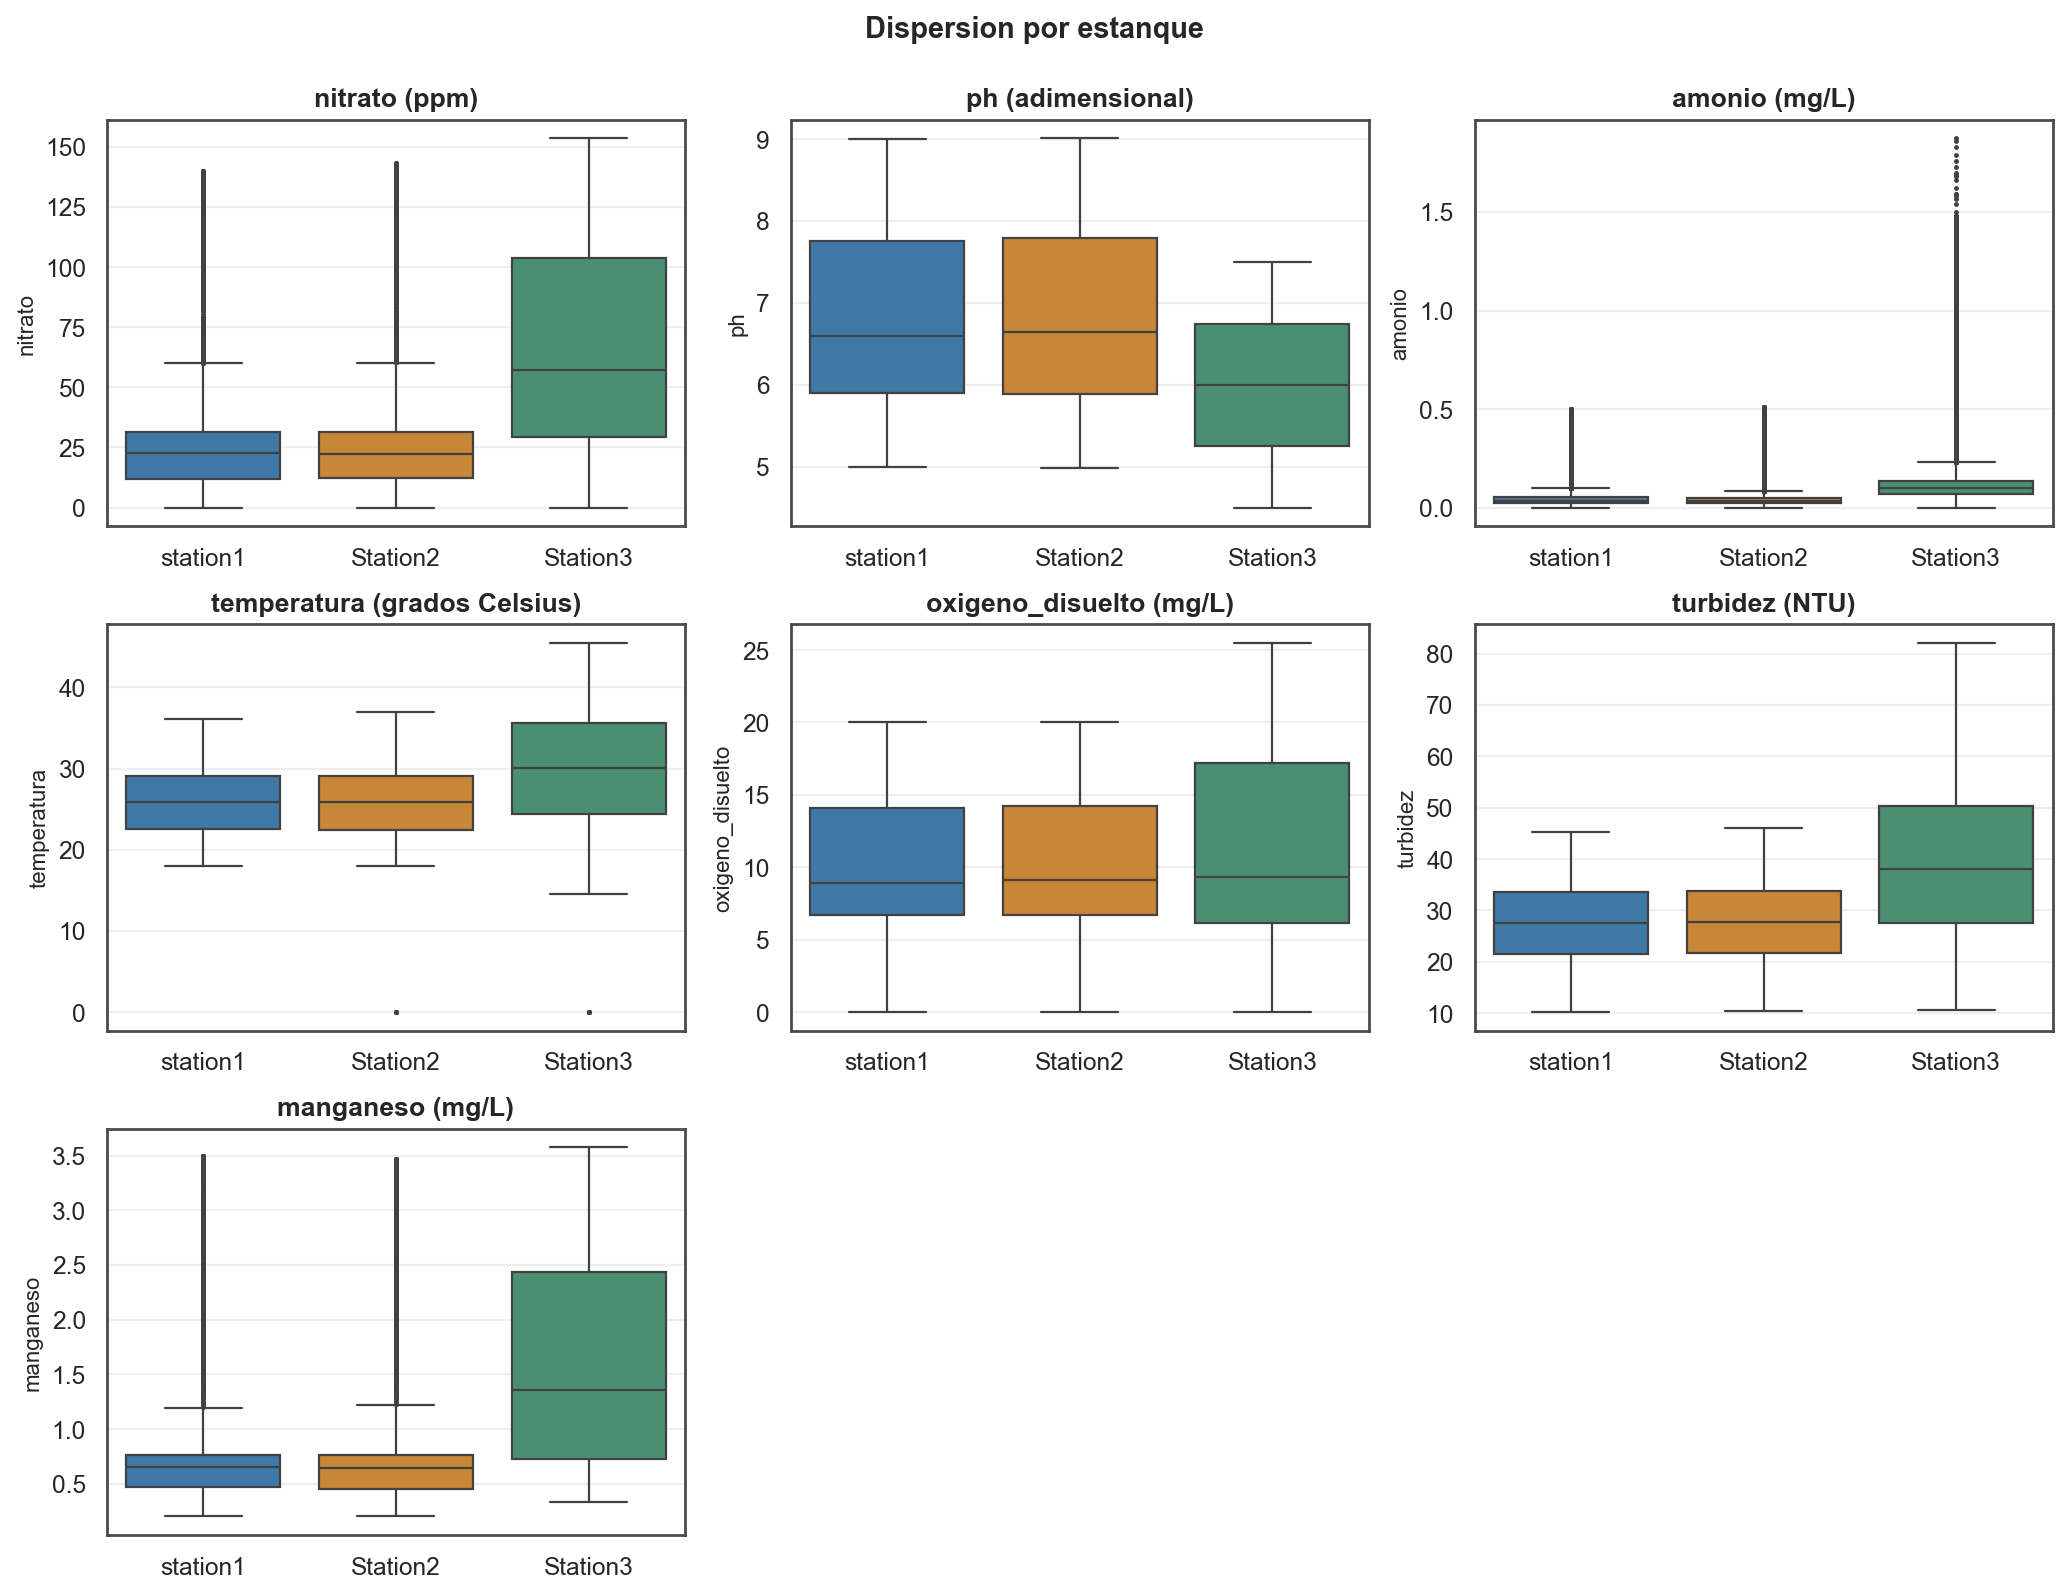

In [22]:
fig_cajas = graficos.cajas_por_estanque(df_num.dropna(subset=["estanque"]))
display(Image(filename=str(fig_cajas)))

---
## 4. Estructura temporal del registro

Ésta es la parte decisiva de la exploración: el dataset no es una tabla de
observaciones independientes, sino **tres series de tiempo paralelas**. Antes de
limpiar hay que saber si el eje temporal se puede reconstruir y con qué cobertura.

In [23]:
df_ts = temporal.construir_timestamp(df_num)

print(f"Timestamps no parseables: {df_ts['timestamp'].isna().sum()}")
print(f"  - de filas completamente vacias: {filas_vacias.sum()}")
print(f"  - con fecha pero sin hora:       "
      f"{int(df_ts['timestamp'].isna().sum() - filas_vacias.sum())}")
print()
print(f"Rango temporal: {df_ts['timestamp'].min()}  ->  {df_ts['timestamp'].max()}")

Timestamps no parseables: 89
  - de filas completamente vacias: 38
  - con fecha pero sin hora:       51

Rango temporal: 2022-02-01 00:00:00  ->  2023-01-21 23:40:00


**Hallazgo H-07 — 51 registros tienen fecha pero no hora.** No se puede reconstruir la
hora sin inventar información: heredarla de la fila anterior fabricaría una cadencia
que no se observó. Como una observación sin instante es inutilizable en un análisis
temporal, esas 51 filas (0,07 %) se descartan de forma explícita y documentada.

> **Nota sobre el formato de fecha.** El archivo usa `dd-mm-yyyy`. El formato se
> declara de manera explícita en `temporal.construir_timestamp` en lugar de dejar que
> pandas lo infiera: la inferencia automática interpretaría `01-02-2022` como 1 de
> febrero o 2 de enero según la fila, corrompiendo el orden temporal en silencio.

→ *Se traduce en la etapa 6 (`construir_eje_temporal`).*

In [24]:
cobertura = temporal.resumen_cobertura(df_ts.dropna(subset=["estanque"]))
cobertura

,estanque,inicio,fin,dias_cubiertos,lecturas_observadas,lecturas_esperadas,lecturas_faltantes,cobertura_pct
0,Station2,2022-02-01,2023-01-21 23:40:00,355.0,25481,25560,79,99.69
1,Station3,2022-02-01,2023-01-20 15:00:00,353.6,25444,25462,18,99.93
2,station1,2022-02-01,2022-12-28 23:40:00,331.0,23782,23832,50,99.79


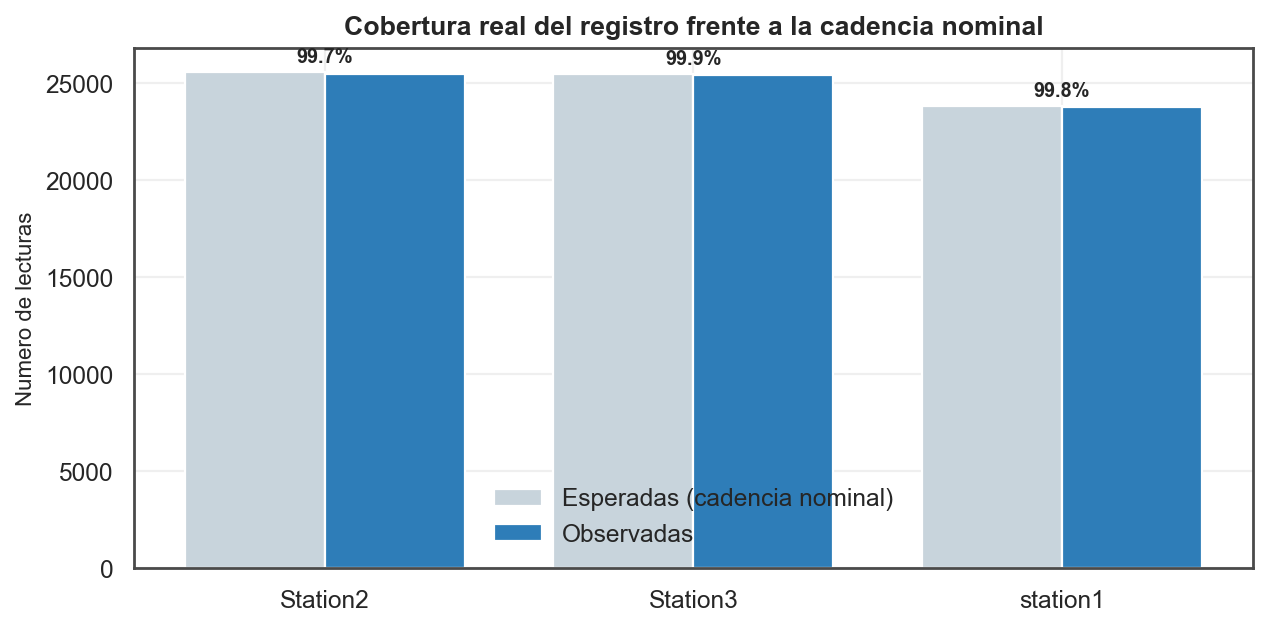

In [25]:
fig_cob = graficos.cobertura_registro(cobertura)
display(Image(filename=str(fig_cob)))

**Hallazgo H-08 — Las tres ventanas de observación son de distinta duración.** Los tres
estanques arrancan el 01-02-2022, pero `station1` deja de registrar el 28-12-2022,
casi un mes antes que los otros dos. No es un defecto del dato: es una característica
del registro que debe conocerse para no confundir el fin del monitoreo con una pérdida
de información.

In [26]:
huecos = temporal.detectar_huecos(df_ts.dropna(subset=["estanque"]))

print(f"Interrupciones detectadas: {len(huecos)}")
print(f"Lecturas perdidas totales: {int(huecos['lecturas_perdidas'].sum())}")
huecos

Interrupciones detectadas: 10
Lecturas perdidas totales: 147


,estanque,ultima_lectura,siguiente_lectura,duracion_min,lecturas_perdidas
0,Station2,2023-01-21 03:20:00,2023-01-21 23:40:00,1220.0,60
1,station1,2022-12-28 13:00:00,2022-12-28 23:40:00,640.0,31
2,Station3,2022-09-14 01:40:00,2022-09-14 07:40:00,360.0,17
3,Station2,2022-09-14 01:40:00,2022-09-14 07:20:00,340.0,16
4,station1,2022-09-14 01:40:00,2022-09-14 07:20:00,340.0,16
5,Station2,2022-02-01 07:00:00,2022-02-01 08:00:00,60.0,2
6,station1,2022-02-01 07:00:00,2022-02-01 08:00:00,60.0,2
7,Station2,2022-09-15 23:20:00,2022-09-16 00:00:00,40.0,1
8,Station3,2022-02-01 07:20:00,2022-02-01 08:00:00,40.0,1
9,station1,2022-09-15 23:20:00,2022-09-16 00:00:00,40.0,1


**Hallazgo H-09 — El registro es casi continuo, con pocas interrupciones puntuales.**
La cadencia de 20 minutos se cumple en más del 99,9 % de los intervalos. La tabla
anterior lista cada interrupción: van desde 40 minutos hasta unas 20 horas.

Este resultado condiciona directamente la estrategia de imputación: **no todos los
huecos admiten el mismo tratamiento**. Interpolar un hueco de 40 minutos es razonable
porque las variables físicas tienen inercia en esa escala; interpolar uno de 20 horas
fabricaría una recta donde pudo haber un evento crítico.

→ *Se traduce en las etapas 9 (`regularizar_frecuencia`) y 10 (`tratar_nulos`), esta
última con un límite estricto de tres lecturas consecutivas (1 hora).*

In [27]:
# Distribucion de los huecos por duracion, que sustenta el limite de interpolacion.
if len(huecos):
    huecos.assign(
        categoria=pd.cut(
            huecos["duracion_min"],
            bins=[20, 60, 180, 10**6],
            labels=["Corto (<= 1 h)", "Medio (1-3 h)", "Largo (> 3 h)"],
        )
    ).groupby("categoria", observed=False).agg(
        n_huecos=("duracion_min", "size"),
        lecturas_perdidas=("lecturas_perdidas", "sum"),
    )

### 4.1 Visualización de las series de tiempo

Las series se agregan a media diaria antes de graficarlas: a la cadencia original de
20 minutos, un año de datos son unos 75.000 puntos por estanque y la línea se
convierte en una mancha sin tendencia legible. La banda verde indica el rango
operacional de referencia para acuicultura; se muestra **sólo como contexto visual**,
los valores fuera de ella no se alteran en ningún momento.

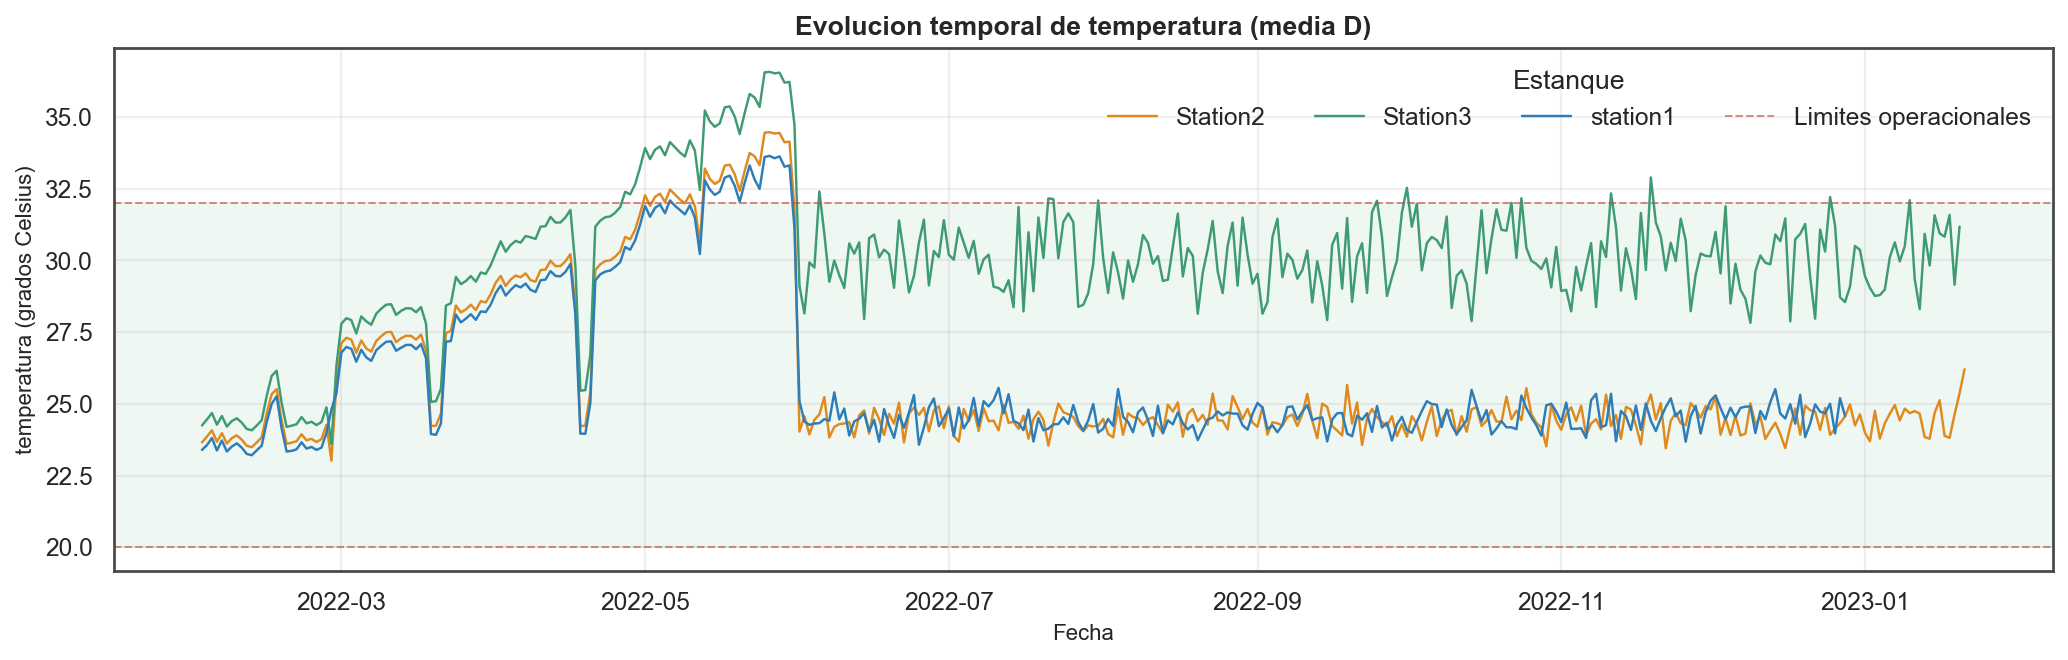

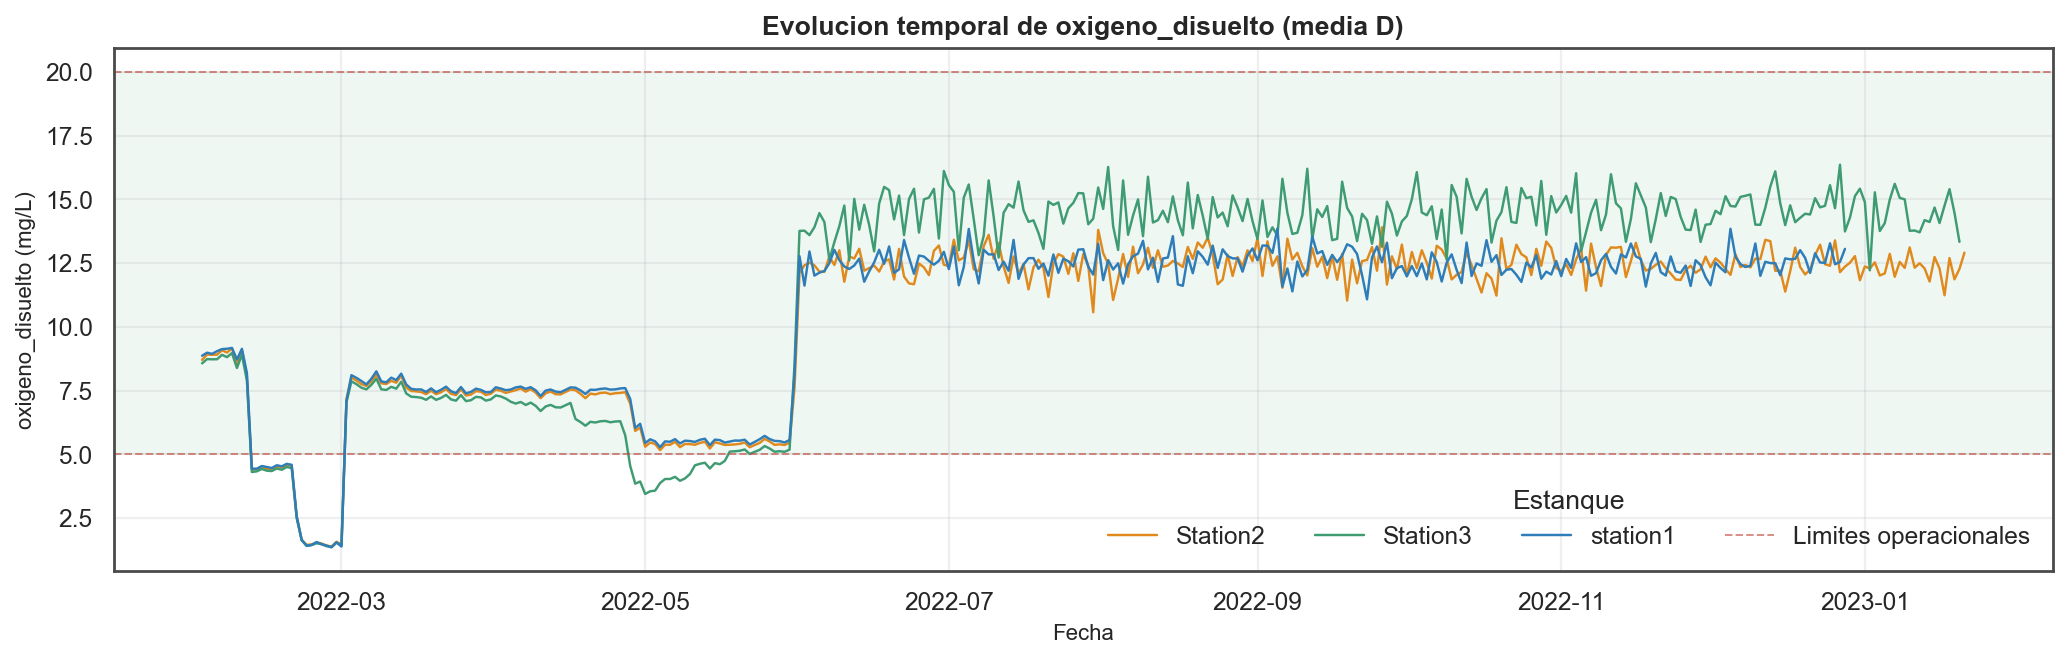

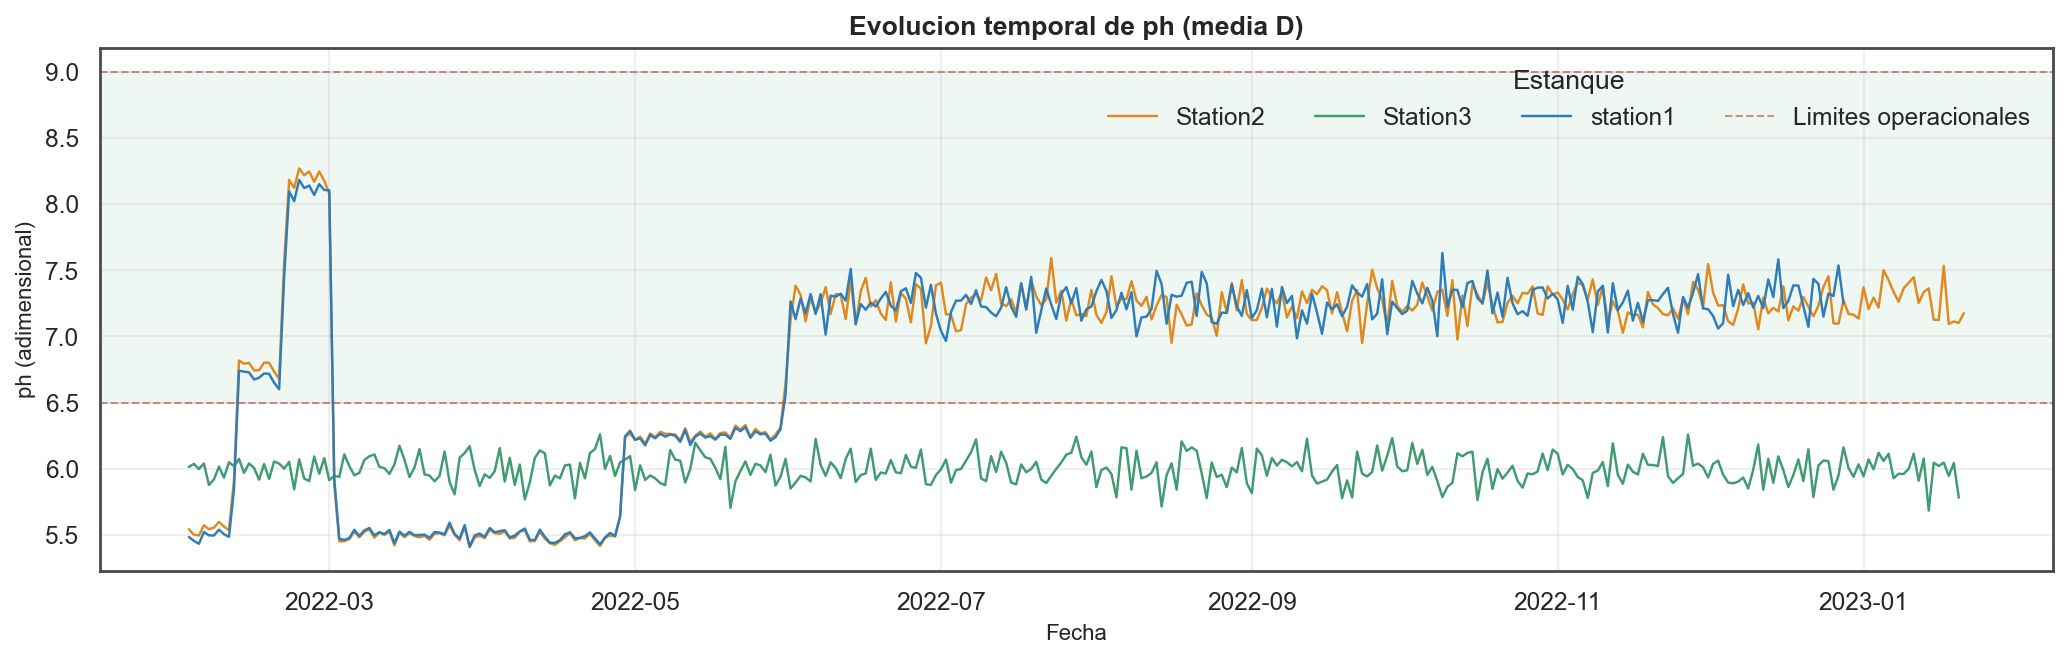

In [28]:
for variable in ["temperatura", "oxigeno_disuelto", "ph"]:
    ruta = graficos.serie_temporal(df_ts.dropna(subset=["estanque"]), variable)
    display(Image(filename=str(ruta)))

---
## 5. Síntesis: de los hallazgos al pipeline

La exploración produjo nueve hallazgos, y cada uno determina una etapa concreta del
pipeline que se implementa en `F2_02`. Esta correspondencia es lo que hace que la
limpieza sea justificada y no una secuencia de operaciones por costumbre.

In [29]:
sintesis = pd.DataFrame(
    [
        ("H-01", "Ninguna columna tiene el tipo correcto (todas object)", "E5  convertir_tipos"),
        ("H-02", "38 filas completamente vacias aportan 418 de 498 nulos", "E3  eliminar_filas_vacias"),
        ("H-03", "13 celdas '#VALUE!' y 7 cadenas 'NaN' literales", "E2  normalizar_centinelas"),
        ("H-04", "Capitalizacion inconsistente en 'station'", "E4  normalizar_estanque"),
        ("H-05", "37 duplicados exactos, derivados de las filas vacias", "E7  eliminar_duplicados"),
        ("H-06", "12 temperaturas de 0.0 C: fallo de sensor del 27-02-2022", "E8  anular_fallos_de_sensor"),
        ("H-07", "51 registros con fecha pero sin hora", "E6  construir_eje_temporal"),
        ("H-08", "Ventanas de observacion desiguales entre estanques", "E9  regularizar_frecuencia"),
        ("H-09", f"{len(huecos)} interrupciones del registro, de 40 min a ~20 h", "E10 tratar_nulos (limite 1 h)"),
    ],
    columns=["hallazgo", "descripcion", "etapa_del_pipeline"],
)
sintesis

,hallazgo,descripcion,etapa_del_pipeline
0,H-01,Ninguna columna tiene el tipo correcto (todas ...,E5 convertir_tipos
1,H-02,38 filas completamente vacias aportan 418 de 4...,E3 eliminar_filas_vacias
2,H-03,13 celdas '#VALUE!' y 7 cadenas 'NaN' literales,E2 normalizar_centinelas
3,H-04,Capitalizacion inconsistente en 'station',E4 normalizar_estanque
4,H-05,"37 duplicados exactos, derivados de las filas ...",E7 eliminar_duplicados
5,H-06,12 temperaturas de 0.0 C: fallo de sensor del ...,E8 anular_fallos_de_sensor
6,H-07,51 registros con fecha pero sin hora,E6 construir_eje_temporal
7,H-08,Ventanas de observacion desiguales entre estan...,E9 regularizar_frecuencia
8,H-09,"10 interrupciones del registro, de 40 min a ~20 h",E10 tratar_nulos (limite 1 h)


### Conclusiones de la exploración

1. **El dataset es utilizable, pero no tal como viene.** Los defectos afectan a una
   fracción muy pequeña de las filas (menos del 0,2 %), pero bastan para impedir
   cualquier operación numérica: veinte celdas contaminadas dejan cuatro variables
   como texto.

2. **El eje temporal se puede reconstruir con alta fidelidad.** La cadencia de 20
   minutos se respeta en más del 99,9 % de los intervalos, lo que permite construir
   una rejilla temporal regular sin imputación masiva.

3. **Hay que distinguir dos clases de valor anómalo.** Los ceros de temperatura son
   fallos de instrumento y deben anularse; los valores fuera del rango operacional
   seguro son mediciones válidas de eventos reales y deben conservarse. Confundirlos
   destruiría justamente la información de interés.

4. **El orden de las etapas no es indiferente.** Eliminar duplicados antes de eliminar
   filas vacías daría un resultado distinto y peor; convertir tipos antes de unificar
   los centinelas perdería la trazabilidad de cuántos valores estaban enmascarados.

### Continuación

- **`F2_02_Limpieza_Transformacion.ipynb`** — implementa el pipeline de doce etapas
  derivado de esta tabla, con reporte *antes → después* en cada una.
- **`F2_03_Validacion.ipynb`** — verifica el resultado mediante contratos de calidad y
  pruebas de casos normales, límite y de excepción.